Device:cuda  N0=4  K=4  gamma=0.0625  q=8b  epochs=200
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='train'  K=4 ...
  Loaded: 40000 samples x 4 users.
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='val'  K=4 ...
  Loaded: 4000 samples x 4 users.
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='test'  K=4 ...
  Loaded: 4000 samples x 4 users.
Global norm  min=-1.4087e-07  max=1.4035e-07
Params: 110,944
Training 200 epochs ...
  Saved -> /kaggle/output/mu_jdcnet_n04_k4_best.pth  (0.48 MB)
Ep   1/200 | lr=5.00e-05 | loss=1.6774e-01 | val_avg=12.558dB [U1:12.33dB  U2:12.32dB  U3:12.81dB  U4:12.76dB] | best=12.558dB | 13.4s
  Saved -> /kaggle/output/mu_jdcnet_n04_k4_best.pth  (0.48 MB)
  Saved -> /kaggle/output/mu_jdcnet_n04_k4_best.pth  (0.48 MB)
  Saved -> /kaggle/output/mu_jdcnet_n04_k4_best.pth  (0.48 MB)
  Saved -> /kagg

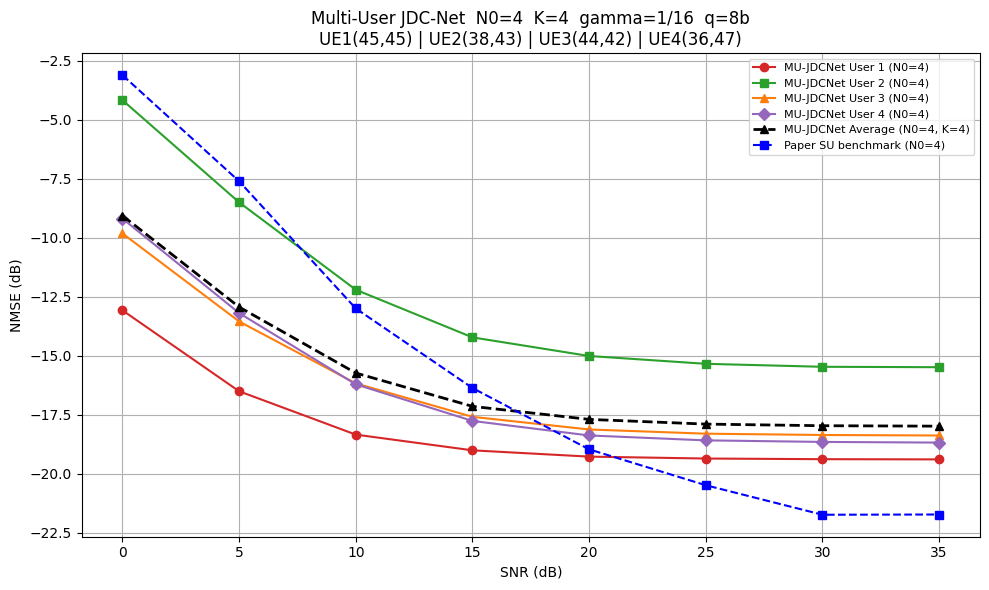

In [1]:
# ================================================================
# Multi-User JDC-Net  |  N0 = 4  |  K = 4 users  |  v1 (fast)
# Dataset: RIS_Channels_MU_K4.mat  (MATLAB v7.3 HDF5, SimRIS_v18)
# ================================================================

import os, random, math, time, shutil
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


# ================================================================
# Flexible state-dict loader
# ================================================================
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if   'model_state_dict' in sd: sd = sd['model_state_dict']
        elif 'state_dict'       in sd: sd = sd['state_dict']
    sd_keys = list(sd.keys())
    if not sd_keys: raise RuntimeError('Empty state_dict')
    shm = sd_keys[0].startswith('module.')
    idp = isinstance(model, nn.DataParallel)
    if shm and not idp:  sd = {k[7:]: v for k, v in sd.items()}
    elif (not shm) and idp: sd = {'module.' + k: v for k, v in sd.items()}
    model.load_state_dict(sd)
    if verbose: print(f'[loader] Loaded from {path}')


# ================================================================
# STE Quantizer
# ================================================================
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        L = 2**q_bits - 1
        return torch.round(torch.clamp(x, 0., 1.) * L) / L
    @staticmethod
    def backward(ctx, g): return g, None


# ================================================================
# ResBlock
# ================================================================
class PaperResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.c2 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.R  = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.R(self.c2(self.R(self.c1(x))) + x)


# ================================================================
# Per-user decoder
# ================================================================
class _UserDecoder(nn.Module):
    def __init__(self, C, dch, B, N0):
        super().__init__()
        self.tc1 = nn.ConvTranspose2d(C,   dch, 4, 2, 1)
        self.tc2 = nn.ConvTranspose2d(dch, dch, 4, 2, 1)
        self.res = nn.Sequential(*[PaperResBlock(dch) for _ in range(B)])
        self.ftc = nn.ConvTranspose2d(dch, dch,
                                       kernel_size=(1, 2*N0),
                                       stride=(1, N0),
                                       padding=(0, N0//2))
        self.fc  = nn.Conv2d(dch, 2, 3, 1, 1)
    def forward(self, z):
        y = torch.relu(self.tc1(z))
        y = torch.relu(self.tc2(y))
        y = self.res(y)
        y = torch.relu(self.ftc(y))
        return self.fc(y)


# ================================================================
# Multi-User JDC-Net
# ================================================================
class MU_JDCNet(nn.Module):
    def __init__(self, M=16, N=64, N0=4, K=4,
                 gamma=1/16, q_bits=8, B=4, decoder_ch=16,
                 quant_enabled=True):
        super().__init__()
        self.K, self.N0, self.q_bits = K, N0, q_bits
        self.quant_enabled = quant_enabled
        self.C = int(gamma * 32 * N0)
        self.encoder = nn.Sequential(
            nn.Conv2d(2,   16,    4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, 4, 2, 1)
        )
        self.decoders = nn.ModuleList(
            [_UserDecoder(self.C, decoder_ch, B, N0) for _ in range(K)]
        )

    def _bottleneck(self, lst):
        z = None
        for k in range(self.K):
            zk = self.encoder(lst[k])
            z  = zk if z is None else z + zk
        zs  = z.shape
        v   = z.view(zs[0], -1)
        vmn = v.min(1, keepdim=True)[0]
        vmx = v.max(1, keepdim=True)[0]
        den = (vmx - vmn).clamp_min(1e-12)
        if self.quant_enabled:
            vn  = (v - vmn) / den
            vq  = QuantizeSTE.apply(vn, self.q_bits)
            v   = vq * den + vmn
        return v.view(*zs)

    def forward(self, lst):
        z = self._bottleneck(lst)
        return [self.decoders[k](z) for k in range(self.K)]


# ================================================================
# h5py helper for MATLAB v7.3 complex arrays
# MATLAB v7.3 = HDF5, arrays stored transposed (Fortran order):
#   MATLAB H  (64,16,S) -> h5py (S,16,64)
#   MATLAB G_k(1,64,S)  -> h5py (S,64,1)
# ================================================================
def _load_cplx(f, key):
    ds = f[key]
    if ds.dtype.names is not None and 'real' in ds.dtype.names:
        arr = ds['real'][()] + 1j * ds['imag'][()]
    else:
        arr = ds[()]
    return arr.astype(np.complex64)


# ================================================================
# Multi-User Dataset
# ================================================================
class MURISChannelDataset(Dataset):
    """
    H  (64,16,S) -> h5py (S,16,64) -> .T(0,2,1) -> (S,64,16)
    G_k(1,64,S)  -> h5py (S,64,1)  -> .T(0,2,1) -> (S,1,64)
    Cascaded: Hc_k = G_k.T(0,2,1) * H_s  -> (S,64,16)
    Final: (S,2,16,64) float32
    """
    def __init__(self, mat_file, split='train', K=4):
        print(f"Loading {mat_file}  split='{split}'  K={K} ...")
        G_keys = [f'G_{k+1}' for k in range(K)]
        sl = {'train': slice(0,40000),
              'val':   slice(40000,44000),
              'test':  slice(44000,48000)}[split]

        with h5py.File(mat_file, 'r') as f:
            missing = [key for key in ['H'] + G_keys if key not in f]
            if missing:
                raise KeyError(f"Missing keys {missing}. Available: {list(f.keys())}")

            H_raw = _load_cplx(f, 'H')        # (S,16,64)
            H_mat = H_raw.transpose(0, 2, 1)  # (S,64,16)
            H_s   = H_mat[sl]

            self.user_data = []
            for key in G_keys:
                G_raw = _load_cplx(f, key)              # (S,64,1)
                G_k   = G_raw.transpose(0, 2, 1)[sl]    # (split,1,64)
                Hc_k  = G_k.transpose(0, 2, 1) * H_s   # (split,64,16)
                real  = np.real(Hc_k).astype(np.float32)
                imag  = np.imag(Hc_k).astype(np.float32)
                stk   = np.stack([real, imag], axis=1).transpose(0, 1, 3, 2)  # (split,2,16,64)
                self.user_data.append(torch.tensor(stk, dtype=torch.float32))

        self.K = K
        print(f"  Loaded: {len(self.user_data[0])} samples x {K} users.")

    def __len__(self):  return len(self.user_data[0])
    def __getitem__(self, i): return tuple(self.user_data[k][i] for k in range(self.K))


# ================================================================
# LS pilot generator
# ================================================================
def generate_ls_physical(H_phys, N0, snr_db):
    """H_phys (B,2,M,N) -> noisy grouped LS estimate (B,2,M,Np)"""
    b, c, m, n = H_phys.shape
    assert n % N0 == 0
    Hg  = H_phys.view(b, c, m, n//N0, N0).mean(-1)
    pwr = torch.mean(Hg[:,0]**2 + Hg[:,1]**2, dim=[1,2])
    std = torch.sqrt(pwr / (10.0**(snr_db/10.0) * 2.0)).view(b,1,1,1)
    return Hg + torch.randn_like(Hg) * std


# ================================================================
# LR schedule: warm-up + cosine decay
# ================================================================
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * epoch / max(1, Tw)
    t = (epoch - Tw) / max(1, T - Tw)
    return eta_min + 0.5*(eta_max - eta_min)*(1 + math.cos(math.pi*t))


def fwd(model, lst):
    if isinstance(model, nn.DataParallel): return model.module.forward(lst)
    return model(lst)


# ================================================================
# Training + evaluation pipeline
# ================================================================
def run_mu_pipeline(
    mat_path   = '/kaggle/input/YOUR_DATASET/RIS_Channels_MU_K4.mat',
    N0         = 4,
    K          = 4,
    gamma      = 1/16,
    q_bits     = 8,
    batch_size = 256,
    epochs     = 200,
    Tw         = 30,
    eta_max    = 2e-3,
    eta_min    = 5e-5,
    device     = None
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device:{device}  N0={N0}  K={K}  gamma={gamma:.4f}  q={q_bits}b  epochs={epochs}")

    train_ds = MURISChannelDataset(mat_path, 'train', K=K)
    val_ds   = MURISChannelDataset(mat_path, 'val',   K=K)
    test_ds  = MURISChannelDataset(mat_path, 'test',  K=K)

    all_tr = torch.cat([train_ds.user_data[k] for k in range(K)], 0)
    tr_min = float(all_tr.min());  tr_max = float(all_tr.max())
    print(f"Global norm  min={tr_min:.4e}  max={tr_max:.4e}")

    norm   = lambda x: (x - tr_min) / (tr_max - tr_min + 1e-12)
    denorm = lambda x:  x * (tr_max - tr_min) + tr_min

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

    model = MU_JDCNet(M=16, N=64, N0=N0, K=K, gamma=gamma,
                      q_bits=q_bits, B=4, decoder_ch=16, quant_enabled=True)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    model.to(device)
    print(f"Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_nmse = 1e9
    best_path = '/kaggle/working/mu_jdcnet_n04_k4_best.pth'
    out_path  = '/kaggle/output/mu_jdcnet_n04_k4_best.pth'

    print(f"Training {epochs} epochs ...")
    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups: g['lr'] = lr

        tr_loss = 0.;  t0 = time.time()
        for btup in train_dl:
            snr = random.uniform(10, 30)
            ls  = [norm(generate_ls_physical(btup[k].to(device), N0, snr)) for k in range(K)]
            gt  = [norm(btup[k].to(device)) for k in range(K)]
            optimizer.zero_grad()
            out  = fwd(model, ls)
            loss = sum(criterion(out[k], gt[k]) for k in range(K)) / K
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * btup[0].size(0)
        tr_loss /= len(train_dl.dataset)
        t1 = time.time()

        model.eval()
        vm=[0.]*K;  vp=[0.]*K
        with torch.no_grad():
            for vtup in val_dl:
                ls = [norm(generate_ls_physical(vtup[k].to(device), N0, 15.)) for k in range(K)]
                Hp = [vtup[k].to(device) for k in range(K)]
                out = fwd(model, ls)
                for k in range(K):
                    op     = denorm(out[k].cpu())
                    vm[k] += torch.sum((op.to(device) - Hp[k])**2).item()
                    vp[k] += torch.sum(Hp[k]**2).item()
        nk  = [10.*math.log10(vm[k]/(vp[k]+1e-12)) for k in range(K)]
        nav = sum(nk)/K

        if nav < best_nmse:
            best_nmse = nav
            st = model.module.state_dict() if isinstance(model,nn.DataParallel) else model.state_dict()
            torch.save(st, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
                print(f"  Saved -> {out_path}  ({os.path.getsize(out_path)/1e6:.2f} MB)")
            except Exception as e:
                print(f"  Checkpoint warning: {e}")

        if (epoch+1)%10==0 or epoch==0:
            u = '  '.join([f'U{k+1}:{nk[k]:.2f}dB' for k in range(K)])
            print(f"Ep {epoch+1:3d}/{epochs} | lr={lr:.2e} | loss={tr_loss:.4e} | "
                  f"val_avg={nav:.3f}dB [{u}] | best={best_nmse:.3f}dB | {t1-t0:.1f}s")

    # ================================================================
    # Test over SNR grid
    # ================================================================
    load_state_dict_flexible(best_path, model, verbose=True)
    model.eval()
    snrs=[0,5,10,15,20,25,30,35]
    res_k=[[] for _ in range(K)];  res_avg=[]

    with torch.no_grad():
        for snr in snrs:
            tm=[0.]*K;  tp=[0.]*K
            for ttup in test_dl:
                ls = [norm(generate_ls_physical(ttup[k].to(device), N0, snr)) for k in range(K)]
                Hp = [ttup[k].to(device) for k in range(K)]
                out = fwd(model, ls)
                for k in range(K):
                    op     = denorm(out[k].cpu())
                    tm[k] += torch.sum((op.to(device) - Hp[k])**2).item()
                    tp[k] += torch.sum(Hp[k]**2).item()
            nd = [10.*math.log10(tm[k]/(tp[k]+1e-12)) for k in range(K)]
            av = sum(nd)/K
            for k in range(K): res_k[k].append(nd[k])
            res_avg.append(av)
            u = '  '.join([f'U{k+1}:{nd[k]:.3f}dB' for k in range(K)])
            print(f"SNR {snr:2d} dB -> avg {av:.3f} dB  [{u}]")

    # ================================================================
    # Plot
    # ================================================================
    paper_n04 = [-3.11,-7.61,-13.00,-16.37,-18.97,-20.49,-21.74,-21.73]
    colors  = ['tab:red','tab:green','tab:orange','tab:purple']
    markers = ['o','s','^','D']
    plt.figure(figsize=(10,6))
    for k in range(K):
        plt.plot(snrs, res_k[k], marker=markers[k], color=colors[k],
                 label=f'MU-JDCNet User {k+1} (N0={N0})')
    plt.plot(snrs, res_avg, 'k--^', lw=2, label=f'MU-JDCNet Average (N0={N0}, K={K})')
    plt.plot(snrs, paper_n04, 'b--s', label='Paper SU benchmark (N0=4)')
    plt.xlabel('SNR (dB)');  plt.ylabel('NMSE (dB)')
    plt.title(f'Multi-User JDC-Net  N0={N0}  K={K}  gamma=1/16  q={q_bits}b\n'
              'UE1(45,45) | UE2(38,43) | UE3(44,42) | UE4(36,47)')
    plt.grid(True);  plt.legend(fontsize=8);  plt.tight_layout();  plt.show()

    return model, res_k, res_avg


# ================================================================
# Entry point
# ================================================================
mat_path = '/kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat'

model, results_per_user, results_avg = run_mu_pipeline(
    mat_path   = mat_path,
    N0         = 4,
    K          = 4,
    gamma      = 1/16,
    q_bits     = 8,
    batch_size = 256,
    epochs     = 200,
    Tw         = 30,
    eta_max    = 2e-3,
    eta_min    = 5e-5
)
